In [1]:
import pandas as pd
import glob

files = glob.glob(
    "../data/external/ki_endolist/ki-dataset/User*.csv"
)

dfs = [pd.read_csv(f) for f in files]

all_data = pd.concat(dfs)

print(all_data.shape)

(5112, 387)


In [2]:
core_cols = [
    "Cycle day",
    "Period (0-no, 1-yes)",
    "Bleeding (0-no bleeding, 4-heaviest bleeding)",
    "General emotional condition (1-bad, 10-amazing)",
    "General physical condition (1-bad, 10-amazing)",
    "Type of stool (0-no stool, 7-bowel blockage)"
]

df_core = all_data[core_cols]

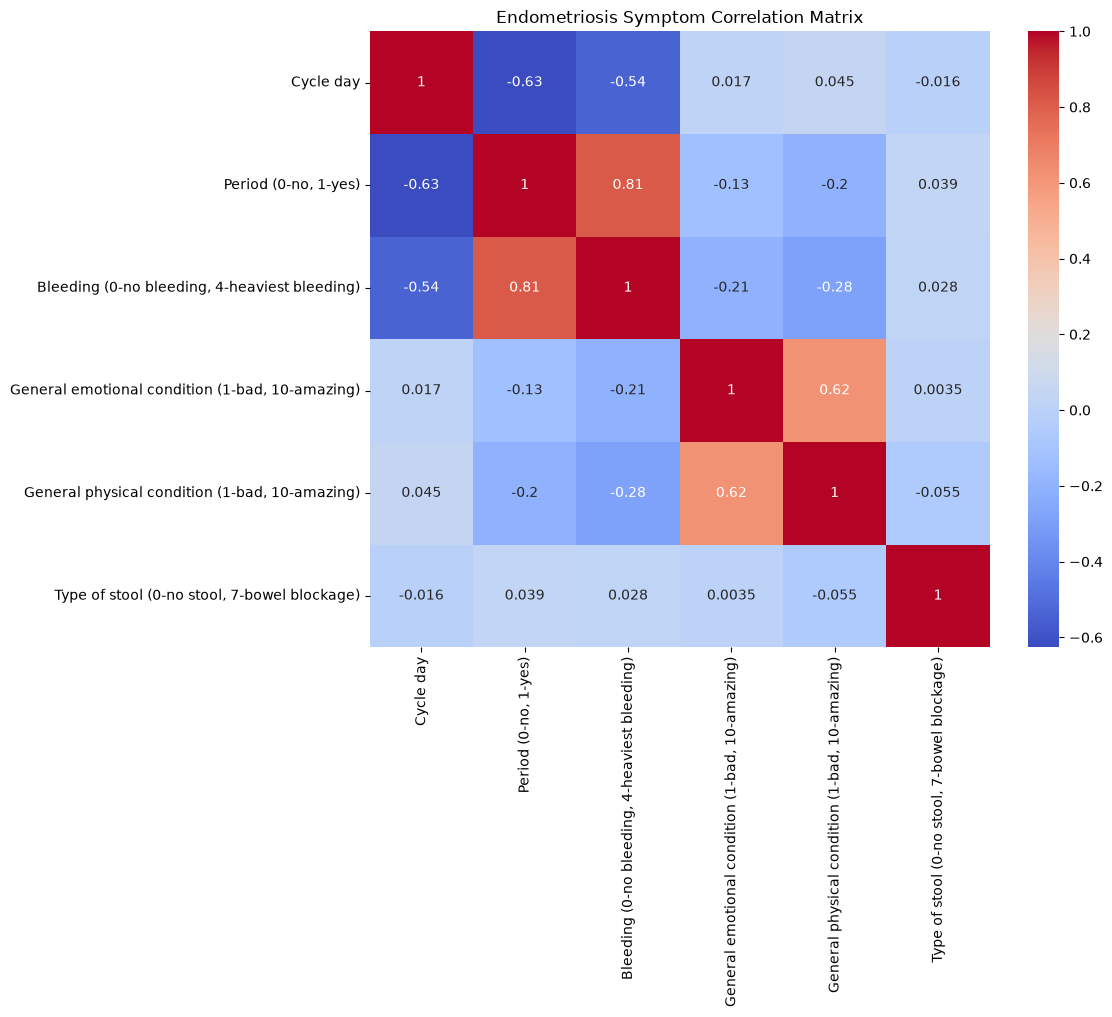

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_core.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Endometriosis Symptom Correlation Matrix")

plt.savefig(
    "../docs/figures/symptom_correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_data = df_core.dropna()

scaler = StandardScaler()

X = scaler.fit_transform(cluster_data)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

cluster_data["Cluster"] = kmeans.fit_predict(X)

cluster_data["Cluster"].value_counts()

Cluster
0    839
2    334
1    305
Name: count, dtype: int64

In [6]:
cluster_data.groupby("Cluster").mean()

,Cycle day,"Period (0-no, 1-yes)","Bleeding (0-no bleeding, 4-heaviest bleeding)","General emotional condition (1-bad, 10-amazing)","General physical condition (1-bad, 10-amazing)","Type of stool (0-no stool, 7-bowel blockage)"
Cluster,,,,,,
0,15.904648,0.005959,0.065554,7.147795,7.146603,3.474374
1,19.718033,0.000000,0.314754,4.573770,4.406557,2.380328
2,3.736527,1.000000,1.970060,5.805389,5.377246,3.095808


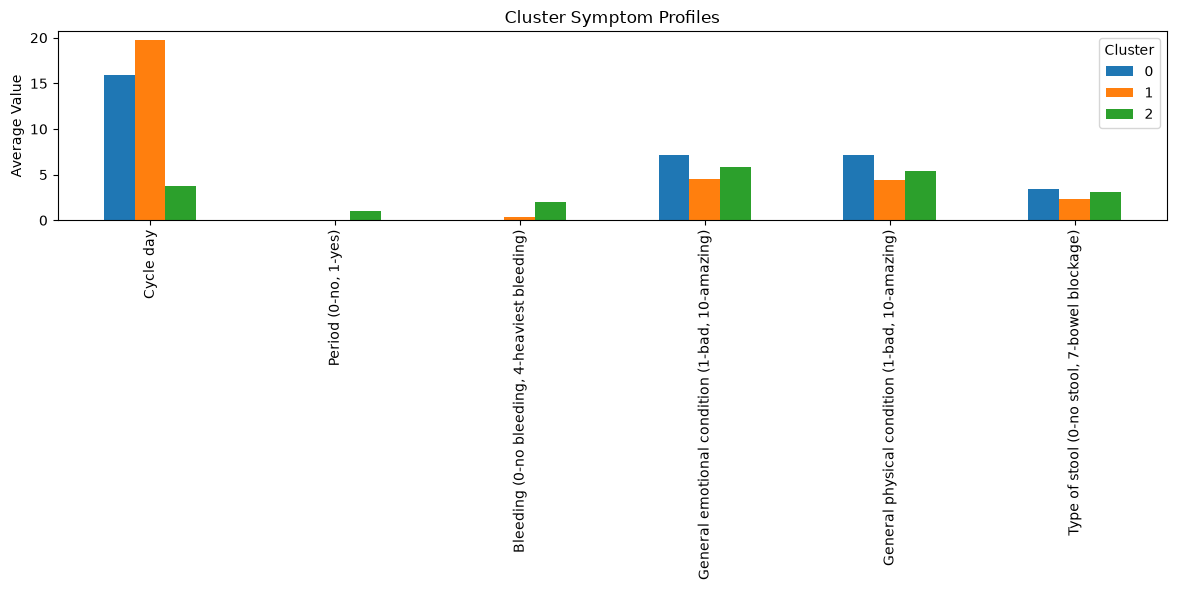

In [7]:
cluster_data.groupby("Cluster").mean().T.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Cluster Symptom Profiles")
plt.ylabel("Average Value")
plt.tight_layout()

plt.savefig(
    "../docs/figures/cluster_profiles.png"
)

plt.show()